ingredient table


In [ ]:
import pandas as pd
import numpy as np

# Load CSV
from google.colab import files
uploaded = files.upload()
import pandas as pd
df = pd.read_csv("restaurant_sales_data.csv")
df


Saving restaurant_sales_data.csv to restaurant_sales_data.csv


,date,restaurant_id,restaurant_type,menu_item_name,meal_type,key_ingredients_tags,typical_ingredient_cost,observed_market_price,actual_selling_price,quantity_sold,has_promotion,special_event,weather_condition
0,1/1/2024,11,Food Stall,Laksa,Lunch,"rice noodles, fish broth, tamarind, shrimp pas...",4.5,10.59,12.48,361,False,False,Sunny
1,1/1/2024,7,Casual Dining,Spaghetti Carbonara,Dinner,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,26.64,60.46,105,False,False,Sunny
2,1/1/2024,23,Fine Dining,Beef Rendang,Dinner,"beef, coconut milk, galangal, lemongrass, spic...",9.0,49.42,80.15,36,False,False,Rainy
3,1/1/2024,22,Food Stall,Roti Canai,Dinner,"flour, ghee, egg, water, curry",0.8,2.04,2.48,503,False,False,Sunny
4,1/1/2024,32,Fine Dining,Spaghetti Carbonara,Lunch,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,40.30,55.54,262,False,False,Rainy
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1/1/2025,45,Food Stall,Cendol,Dinner,"rice flour jelly, coconut milk, palm sugar, re...",2.0,4.41,4.47,588,True,False,Sunny
9996,1/1/2025,44,Food Stall,Teh Tarik,Lunch,"black tea, condensed milk, evaporated milk",0.9,2.44,2.61,511,False,False,Rainy
9997,1/1/2025,38,Fine Dining,Iced Lemon Tea,Dinner,"black tea, lemon, sugar syrup",1.2,6.04,6.91,442,False,False,Sunny
9998,1/1/2025,3,Cafe,Cendol,Lunch,"rice flour jelly, coconut milk, palm sugar, re...",2.0,6.60,8.56,242,False,False,Sunny


In [ ]:
df["date"] = pd.to_datetime(df["date"])


In [ ]:
# Split ingredients into a list
df["ingredient"] = df["key_ingredients_tags"].str.split(",")

ingredients_df = df.explode("ingredient")

ingredients_df["ingredient"] = ingredients_df["ingredient"].str.strip()


In [ ]:
ingredients_df = ingredients_df[
    [
        "date",
        "restaurant_id",
        "restaurant_type",
        "menu_item_name",
        "ingredient",
        "quantity_sold",
        "weather_condition",
        "has_promotion",
        "special_event"
    ]
]


In [ ]:
ingredients_df

,date,restaurant_id,restaurant_type,menu_item_name,ingredient,quantity_sold,weather_condition,has_promotion,special_event
0,2024-01-01,11,Food Stall,Laksa,rice noodles,361,Sunny,False,False
0,2024-01-01,11,Food Stall,Laksa,fish broth,361,Sunny,False,False
0,2024-01-01,11,Food Stall,Laksa,tamarind,361,Sunny,False,False
0,2024-01-01,11,Food Stall,Laksa,shrimp paste,361,Sunny,False,False
0,2024-01-01,11,Food Stall,Laksa,cucumber,361,Sunny,False,False
...,...,...,...,...,...,...,...,...,...
9998,2025-01-01,3,Cafe,Cendol,palm sugar,242,Sunny,False,False
9998,2025-01-01,3,Cafe,Cendol,red beans,242,Sunny,False,False
9999,2025-01-01,38,Fine Dining,Iced Lemon Tea,black tea,276,Cloudy,False,False
9999,2025-01-01,38,Fine Dining,Iced Lemon Tea,lemon,276,Cloudy,False,False


In [ ]:
ingredient_demand = (
    ingredients_df
    .groupby(
        [
            "date",
            "restaurant_id",
            "restaurant_type",
            "ingredient",
            "weather_condition",
            "has_promotion",
            "special_event"
        ],
        as_index=False
    )["quantity_sold"]
    .sum()
)


In [ ]:
ingredient_demand.rename(
    columns={"quantity_sold": "estimated_ingredient_demand"},
    inplace=True
)
ingredient_demand

,date,restaurant_id,restaurant_type,ingredient,weather_condition,has_promotion,special_event,estimated_ingredient_demand
0,2024-01-01,1,Food Stall,butter,Rainy,False,False,347
1,2024-01-01,1,Food Stall,coconut milk,Sunny,False,False,409
2,2024-01-01,1,Food Stall,kaya,Rainy,False,False,347
3,2024-01-01,1,Food Stall,palm sugar,Sunny,False,False,409
4,2024-01-01,1,Food Stall,red beans,Sunny,False,False,409
...,...,...,...,...,...,...,...,...
44678,2025-01-01,45,Food Stall,red beans,Sunny,True,False,588
44679,2025-01-01,45,Food Stall,rice flour jelly,Sunny,True,False,588
44680,2025-01-01,49,Kopitiam,black tea,Cloudy,False,False,950
44681,2025-01-01,49,Kopitiam,condensed milk,Cloudy,False,False,950


In [ ]:
ingredient_daily = (
    ingredient_demand
    .groupby(
        ["date", "ingredient"],
        as_index=False
    )["estimated_ingredient_demand"]
    .sum()
)
ingredient_daily

,date,ingredient,estimated_ingredient_demand
0,2024-01-01,anchovies,315
1,2024-01-01,bean sprouts,236
2,2024-01-01,beef,36
3,2024-01-01,beef bacon,823
4,2024-01-01,black pepper,823
...,...,...,...
17476,2025-01-01,tandoori masala,442
17477,2025-01-01,vegetable broth,245
17478,2025-01-01,water,847
17479,2025-01-01,white bread,1295


In [ ]:
ingredient_demand["date"] = pd.to_datetime(ingredient_demand["date"])

ingredient_weekly = (
    ingredient_demand
    .groupby(
        [
            pd.Grouper(key="date", freq="W"),
            "ingredient"
        ],
        as_index=False
    )["estimated_ingredient_demand"]
    .sum()
)

ingredient_weekly.rename(
    columns={
        "date": "week",
        "estimated_ingredient_demand": "weekly_ingredient_demand"
    },
    inplace=True
)
ingredient_weekly

,week,ingredient,weekly_ingredient_demand
0,2024-01-07,anchovies,4895
1,2024-01-07,bean sprouts,1403
2,2024-01-07,beef,1729
3,2024-01-07,beef bacon,2009
4,2024-01-07,black pepper,2009
...,...,...,...
3069,2025-01-05,tandoori masala,1352
3070,2025-01-05,vegetable broth,809
3071,2025-01-05,water,1831
3072,2025-01-05,white bread,4220


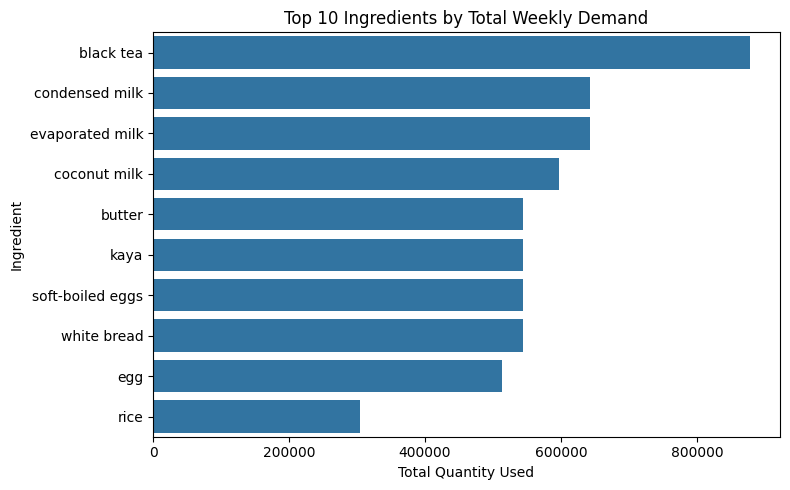

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

top_ingredients = (
    ingredient_weekly
    .groupby("ingredient")["weekly_ingredient_demand"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(
    x=top_ingredients.values,
    y=top_ingredients.index
)

plt.title("Top 10 Ingredients by Total Weekly Demand")
plt.xlabel("Total Quantity Used")
plt.ylabel("Ingredient")
plt.tight_layout()
plt.show()


In [ ]:
small_types = {"Food Stall", "Cafe", "Kopitiam"}

ingredient_weekly_small = ingredient_weekly[
    ingredient_weekly["ingredient"].isin(top_ingredients.index)
]
ingredient_weekly_small

,week,ingredient,weekly_ingredient_demand
6,2024-01-07,black tea,13458
7,2024-01-07,butter,10167
15,2024-01-07,coconut milk,13020
17,2024-01-07,condensed milk,9362
21,2024-01-07,egg,12204
...,...,...,...
3039,2025-01-05,evaporated milk,4603
3048,2025-01-05,kaya,4220
3058,2025-01-05,rice,1424
3063,2025-01-05,soft-boiled eggs,4220


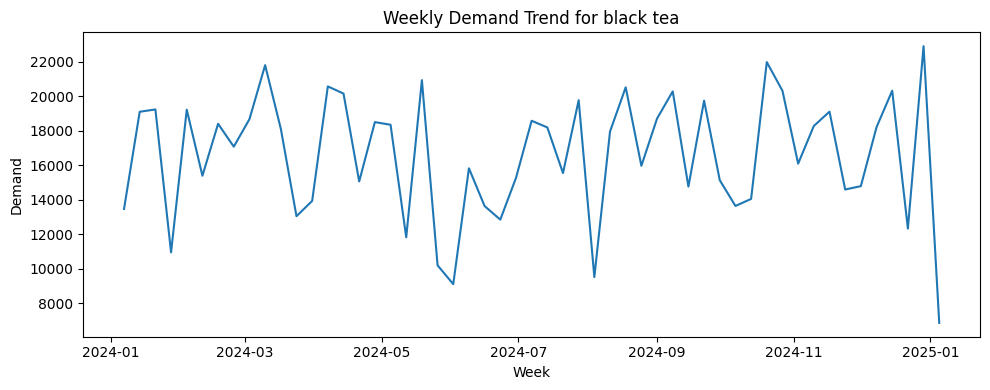

In [ ]:
top_ing = top_ingredients.index[0]

subset = ingredient_weekly[
    ingredient_weekly["ingredient"] == top_ing
]

plt.figure(figsize=(10,4))
plt.plot(
    subset["week"],
    subset["weekly_ingredient_demand"]
)
plt.title(f"Weekly Demand Trend for {top_ing}")
plt.xlabel("Week")
plt.ylabel("Demand")
plt.tight_layout()
plt.show()


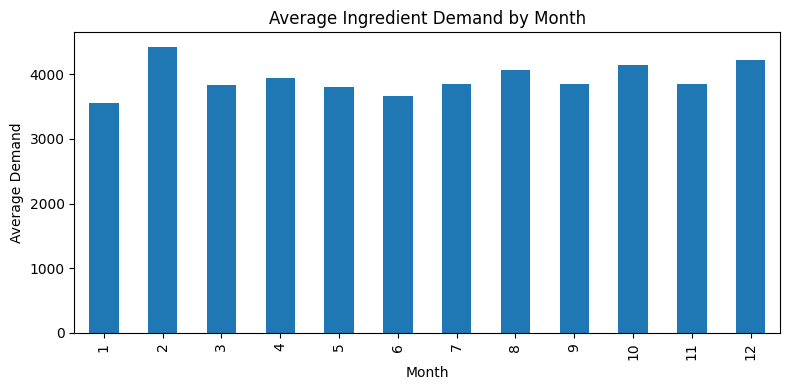

In [ ]:
ingredient_weekly["month"] = ingredient_weekly["week"].dt.month

monthly_pattern = (
    ingredient_weekly
    .groupby("month")["weekly_ingredient_demand"]
    .mean()
)

monthly_pattern.plot(
    kind="bar",
    figsize=(8,4),
    title="Average Ingredient Demand by Month"
)
plt.xlabel("Month")
plt.ylabel("Average Demand")
plt.tight_layout()
plt.show()


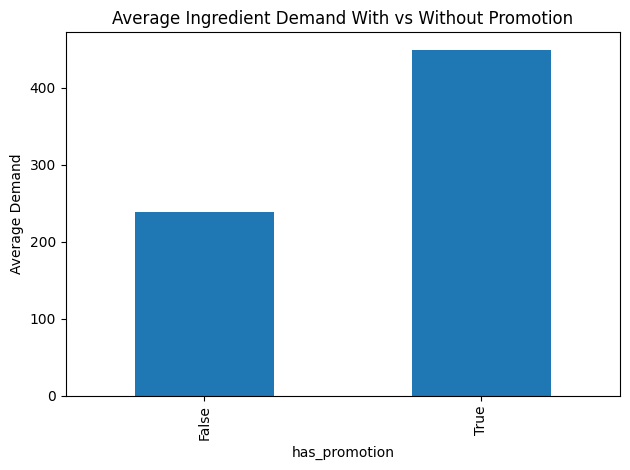

In [ ]:
ingredient_demand["week"] = ingredient_demand["date"].dt.to_period("W").dt.start_time

promo_effect = (
    ingredient_demand
    .groupby("has_promotion")["estimated_ingredient_demand"]
    .mean()
)

promo_effect.plot(
    kind="bar",
    title="Average Ingredient Demand With vs Without Promotion"
)
plt.ylabel("Average Demand")
plt.tight_layout()
plt.show()


In [ ]:


from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt
ingredient_name = "black tea"

df_prophet = (
    ingredient_weekly[ingredient_weekly["ingredient"] == ingredient_name]
    [["week", "weekly_ingredient_demand"]]
    .rename(columns={
        "week": "ds",
        "weekly_ingredient_demand": "y"
    })
    .sort_values("ds")
)


In [ ]:
train_size = int(len(df_prophet) * 0.8)

train_df = df_prophet.iloc[:train_size]
test_df = df_prophet.iloc[train_size:]
model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(train_df)


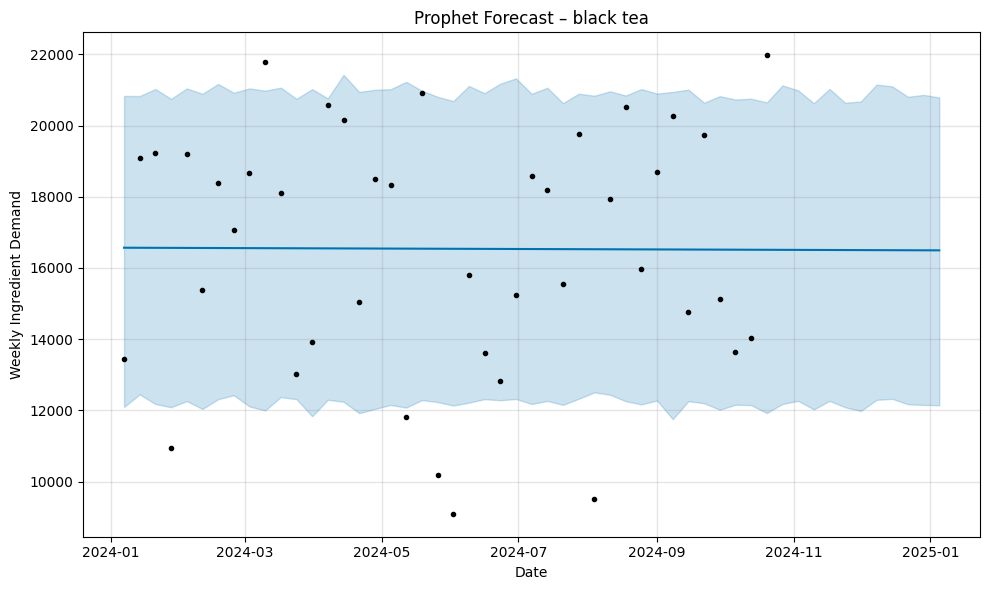

In [ ]:
future = model.make_future_dataframe(
    periods=len(test_df),
    freq="W"
)
forecast = model.predict(future)
model.plot(forecast)
plt.title(f"Prophet Forecast – {ingredient_name}")
plt.xlabel("Date")
plt.ylabel("Weekly Ingredient Demand")
plt.tight_layout()
plt.show()


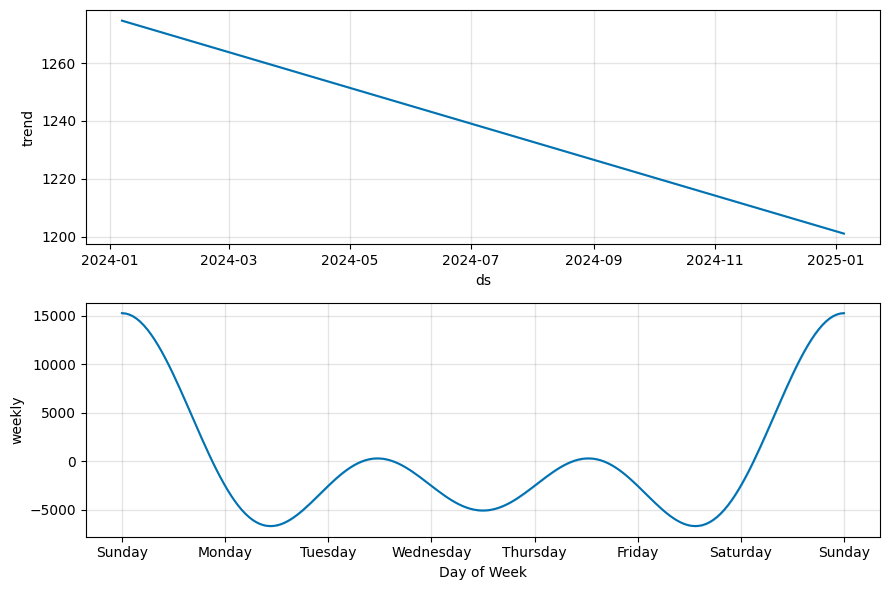

In [ ]:
model.plot_components(forecast)
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

forecast_test = forecast.iloc[train_size:]

rmse = np.sqrt(mean_squared_error(test_df["y"], forecast_test["yhat"]))
mae = mean_absolute_error(test_df["y"], forecast_test["yhat"])

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")


RMSE: 4263.99
MAE: 3450.82


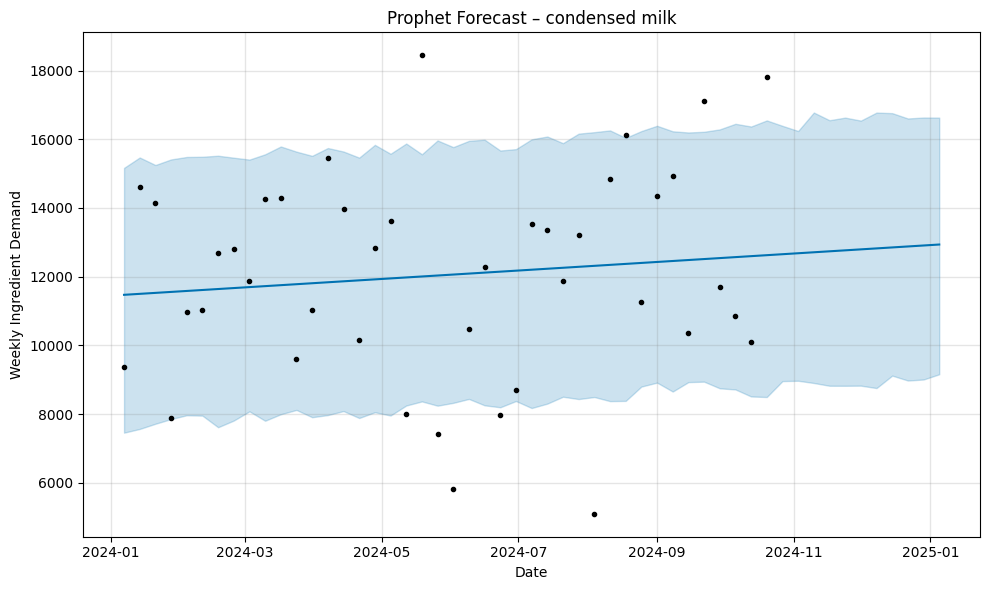

RMSE: 3471.12
MAE: 2427.85


In [ ]:


from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt
ingredient_name = "condensed milk"

df_prophet = (
    ingredient_weekly[ingredient_weekly["ingredient"] == ingredient_name]
    [["week", "weekly_ingredient_demand"]]
    .rename(columns={
        "week": "ds",
        "weekly_ingredient_demand": "y"
    })
    .sort_values("ds")
)
train_size = int(len(df_prophet) * 0.8)

train_df = df_prophet.iloc[:train_size]
test_df = df_prophet.iloc[train_size:]
model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(train_df)
future = model.make_future_dataframe(
    periods=len(test_df),
    freq="W"
)
forecast = model.predict(future)
model.plot(forecast)
plt.title(f"Prophet Forecast – {ingredient_name}")
plt.xlabel("Date")
plt.ylabel("Weekly Ingredient Demand")
plt.tight_layout()
plt.show()
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

forecast_test = forecast.iloc[train_size:]

rmse = np.sqrt(mean_squared_error(test_df["y"], forecast_test["yhat"]))
mae = mean_absolute_error(test_df["y"], forecast_test["yhat"])

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")


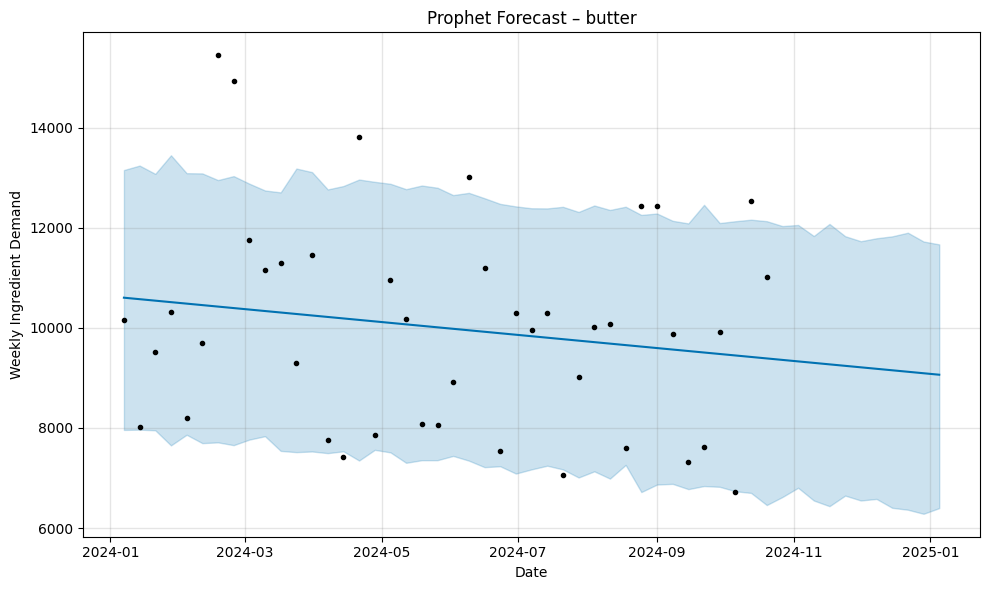

RMSE: 3382.88
MAE: 2929.58


In [ ]:


from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt
ingredient_name = "butter"

df_prophet = (
    ingredient_weekly[ingredient_weekly["ingredient"] == ingredient_name]
    [["week", "weekly_ingredient_demand"]]
    .rename(columns={
        "week": "ds",
        "weekly_ingredient_demand": "y"
    })
    .sort_values("ds")
)
train_size = int(len(df_prophet) * 0.8)

train_df = df_prophet.iloc[:train_size]
test_df = df_prophet.iloc[train_size:]
model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(train_df)
future = model.make_future_dataframe(
    periods=len(test_df),
    freq="W"
)
forecast = model.predict(future)
model.plot(forecast)
plt.title(f"Prophet Forecast – {ingredient_name}")
plt.xlabel("Date")
plt.ylabel("Weekly Ingredient Demand")
plt.tight_layout()
plt.show()
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

forecast_test = forecast.iloc[train_size:]

rmse = np.sqrt(mean_squared_error(test_df["y"], forecast_test["yhat"]))
mae = mean_absolute_error(test_df["y"], forecast_test["yhat"])

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")


In [ ]:
ingredients_df.columns


Index(['date', 'restaurant_id', 'restaurant_type', 'menu_item_name',
       'ingredient', 'quantity_sold', 'weather_condition', 'has_promotion',
       'special_event'],
      dtype='object')

In [ ]:
ingredients_df["date"] = pd.to_datetime(ingredients_df["date"])


In [ ]:
ingredients_df["week"] = (
    ingredients_df["date"]
    .dt.to_period("W")
    .apply(lambda r: r.start_time)
)


In [ ]:
ingredients_df[["date", "week"]].head()


,date,week
0,2024-01-01,2024-01-01
0,2024-01-01,2024-01-01
0,2024-01-01,2024-01-01
0,2024-01-01,2024-01-01
0,2024-01-01,2024-01-01


In [ ]:
weekly_df = (
    ingredients_df
    .groupby([
        "week",
        "ingredient",
        "weather_condition",
        "has_promotion",
        "special_event"
    ], as_index=False)["quantity_sold"]
    .sum()
    .rename(columns={"quantity_sold": "weekly_demand"})
)


In [ ]:
top_ingredients = (
    weekly_df.groupby("ingredient")["weekly_demand"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

weekly_df = weekly_df[weekly_df["ingredient"].isin(top_ingredients)]


In [ ]:
weekly_encoded = pd.get_dummies(
    weekly_df,
    columns=["ingredient", "weather_condition"],
    drop_first=True
)


In [ ]:
weekly_encoded = weekly_encoded.sort_values("week")

X = weekly_encoded.drop(columns=["weekly_demand", "week"])
y = weekly_encoded["weekly_demand"]

split_idx = int(len(weekly_encoded) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")


RMSE: 1043.41
MAE: 701.15
R²: 0.61


In [ ]:
weekly_df = weekly_df.sort_values(["ingredient", "week"])

# Lag features (1, 2, 4 weeks)
for lag in [1, 2, 4]:
    weekly_df[f"lag_{lag}"] = (
        weekly_df
        .groupby("ingredient")["weekly_demand"]
        .shift(lag)
    )

# rolling mean
weekly_df["rolling_4w"] = (
    weekly_df
    .groupby("ingredient")["weekly_demand"]
    .transform(lambda x: x.rolling(4).mean())
)

weekly_df = weekly_df.dropna()


In [ ]:
weekly_encoded = pd.get_dummies(
    weekly_df,
    columns=["ingredient", "weather_condition"],
    drop_first=True
)

weekly_encoded = weekly_encoded.sort_values("week")


In [ ]:
X = weekly_encoded.drop(columns=["weekly_demand", "week"])
y = weekly_encoded["weekly_demand"]

split_idx = int(len(weekly_encoded) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")


RMSE: 788.22
MAE: 574.59
R²: 0.77


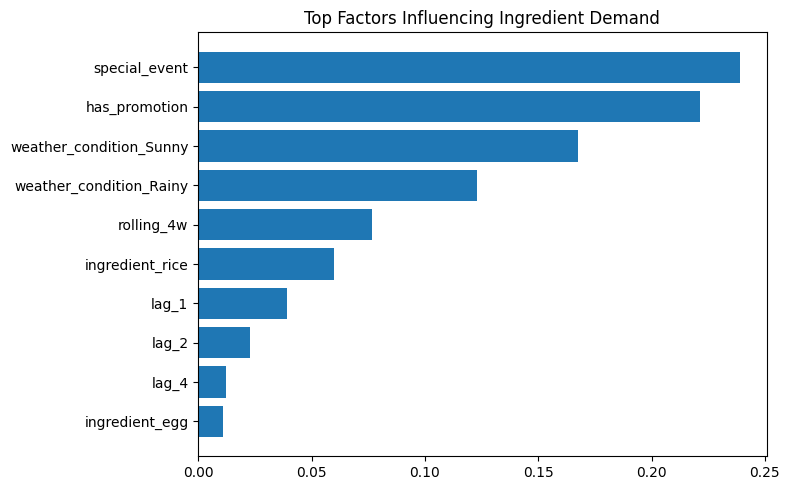

In [ ]:
import matplotlib.pyplot as plt

importance = xgb_model.feature_importances_
features = X_train.columns

fi = pd.DataFrame({
    "feature": features,
    "importance": importance
}).sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.barh(fi["feature"], fi["importance"])
plt.title("Top Factors Influencing Ingredient Demand")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


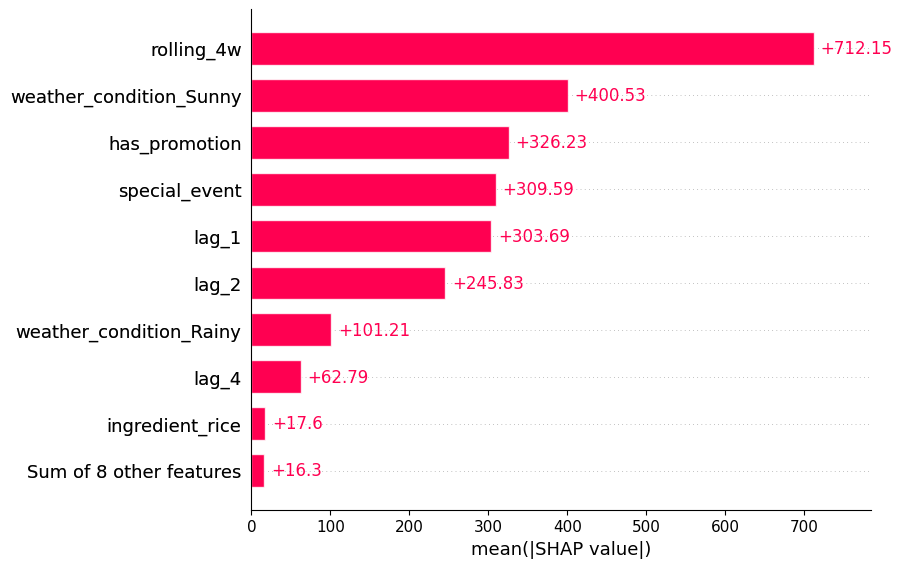

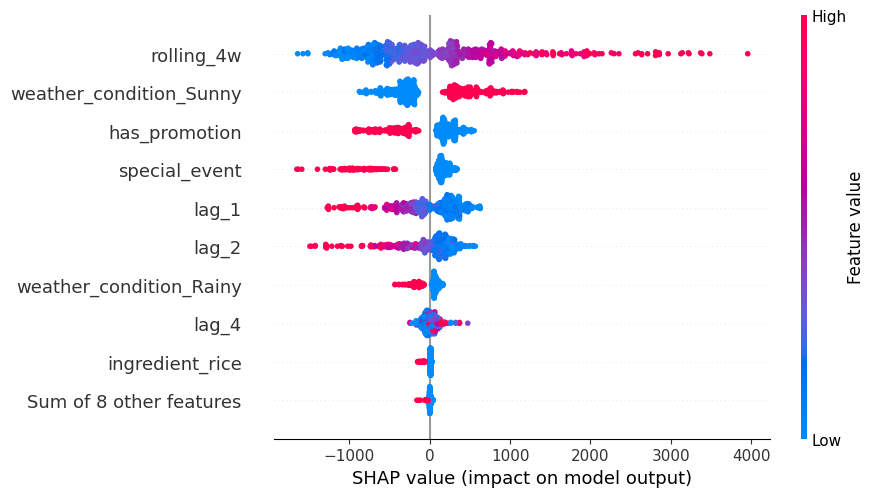

In [ ]:
import shap

explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

# Global importance
shap.plots.bar(shap_values, max_display=10)

# Feature impact distribution
shap.plots.beeswarm(shap_values, max_display=10)


In [ ]:



weekly_df = weekly_df.sort_values(["ingredient", "week"]).reset_index(drop=True)

weekly_encoded = pd.get_dummies(
    weekly_df,
    columns=["ingredient", "weather_condition"],
    drop_first=True
)


X_full = weekly_encoded.drop(columns=["weekly_demand", "week"])


weekly_encoded["predicted_demand"] = xgb_model.predict(X_full)

# BUILD DASHBOARD DATASET

dashboard_df = weekly_df.copy()

dashboard_df.rename(columns={"weekly_demand": "actual_demand"}, inplace=True)

dashboard_df["predicted_demand"] = weekly_encoded["predicted_demand"].values



'''dashboard_df["stock_alert"] = "Normal"

dashboard_df.loc[
    dashboard_df["predicted_demand"] > dashboard_df["actual_demand"] * 1.2,
    "stock_alert"
] = "Understock Risk"

dashboard_df.loc[
    dashboard_df["predicted_demand"] < dashboard_df["actual_demand"] * 0.8,
    "stock_alert"
] = "Overstock Risk"'''

# EXPORT

dashboard_df.to_csv("ingredient_demand_forecast.csv", index=False)

print("Dashboard file exported correctly.")


Dashboard file exported correctly.
